# Phase 8 — Notebook 4: BERT — Deep Architectural Dive

> **Phase Continuity**: Notebook 3 established the two pre-training objectives — MLM (fill-in-the-blank) and CLM (predict-next). This notebook dissects every architectural component of BERT, the model that used MLM to achieve state-of-the-art results on 11 NLP benchmarks simultaneously in 2018.

---

## 1. BERT at a Glance

**B**idirectional **E**ncoder **R**epresentations from **T**ransformers (Devlin et al., 2018, Google AI)

The core architectural insight: take the **Encoder stack** from the Transformer (Phase 7) and pre-train it using Masked Language Modeling. Because Encoders use full bidirectional attention (every token attends to every other), BERT gains rich context from both directions simultaneously.

### BERT Configurations

| | BERT-Base | BERT-Large |
|---|---|---|
| **Transformer Layers** | 12 | 24 |
| **Hidden Dimension** | 768 | 1024 |
| **Attention Heads** | 12 | 16 |
| **Parameters** | 110M | 340M |
| **Training time** | 4 TPU days | 16 TPU days |

---

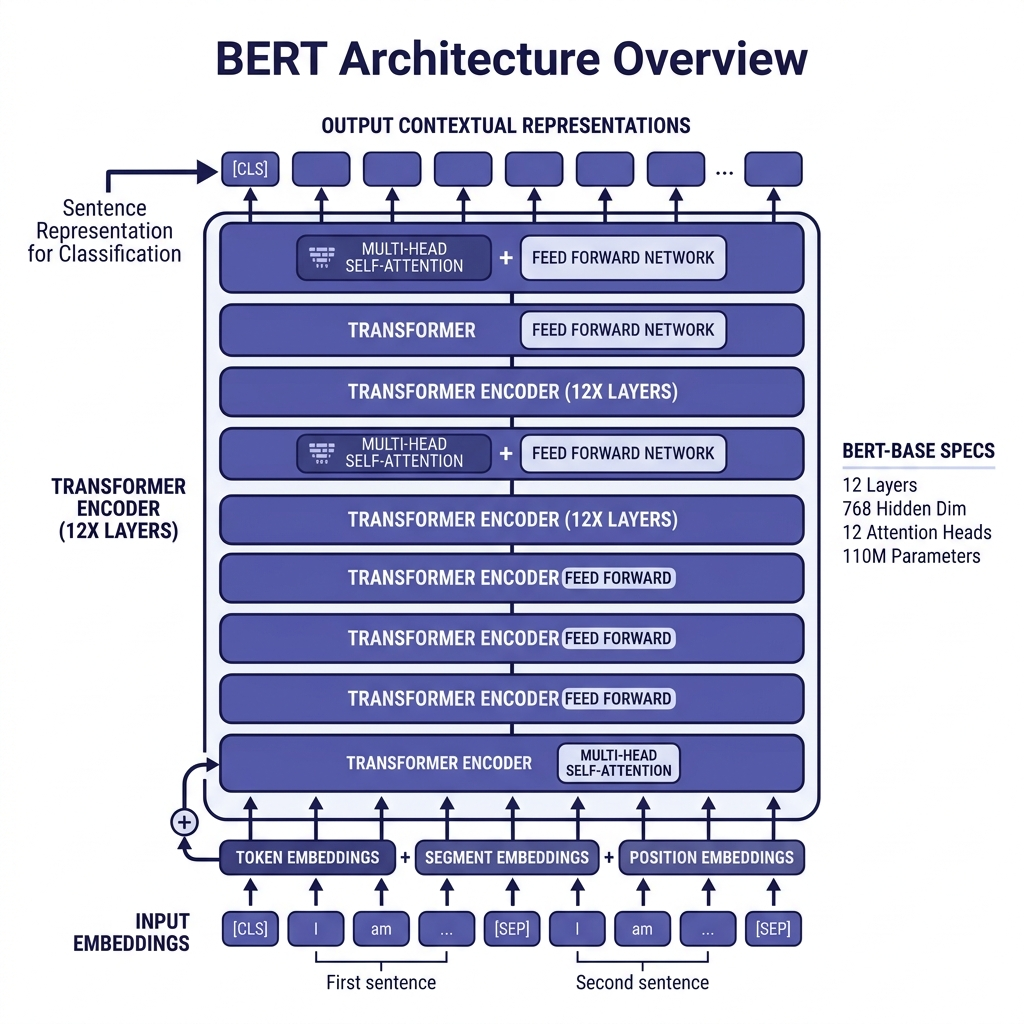

*Figure 1: BERT Architecture — 12 stacked Transformer Encoder blocks with bidirectional attention*



## 2. BERT's Three-Part Input Representation

Before any text enters BERT's Transformer layers, it must be converted into a numerical vector. BERT constructs this by **summing three distinct embedding types** — each contributing a different kind of information:

### 2a. Token Embeddings
A standard learned lookup table: each WordPiece token ID maps to a learned 768-dimensional vector. This captures the **semantic identity** of the token itself (similar to Word2Vec, but now context will be layered on top by the Transformer).

### 2b. Segment Embeddings
BERT often processes **two sentences simultaneously** (for tasks like question answering or natural language inference). Segment embeddings tell BERT which sentence each token belongs to:
- All tokens from Sentence A → Embedding A (a single learned vector)
- All tokens from Sentence B → Embedding B (a different learned vector)

### 2c. Position Embeddings
Unlike the original Transformer which used fixed sinusoidal encodings (Phase 7), BERT uses **fully learned position embeddings** — one vector per position (0 to 511). These allow BERT to learn the most useful positional representations for the pre-training tasks.

The three embeddings are added element-wise: `Final = Token + Segment + Position`

---

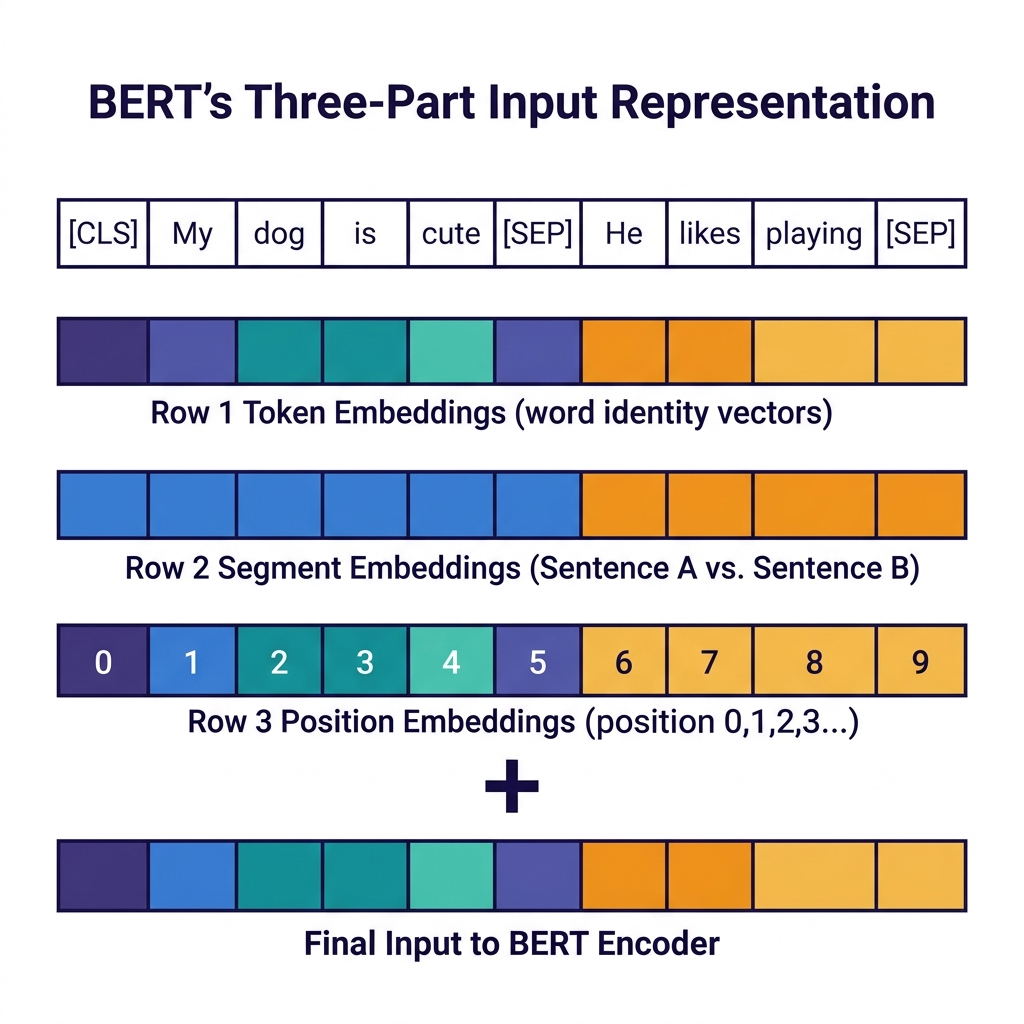

*Figure 2: BERT's three-part input — Token + Segment + Position embeddings are summed before entering the Encoder stack*

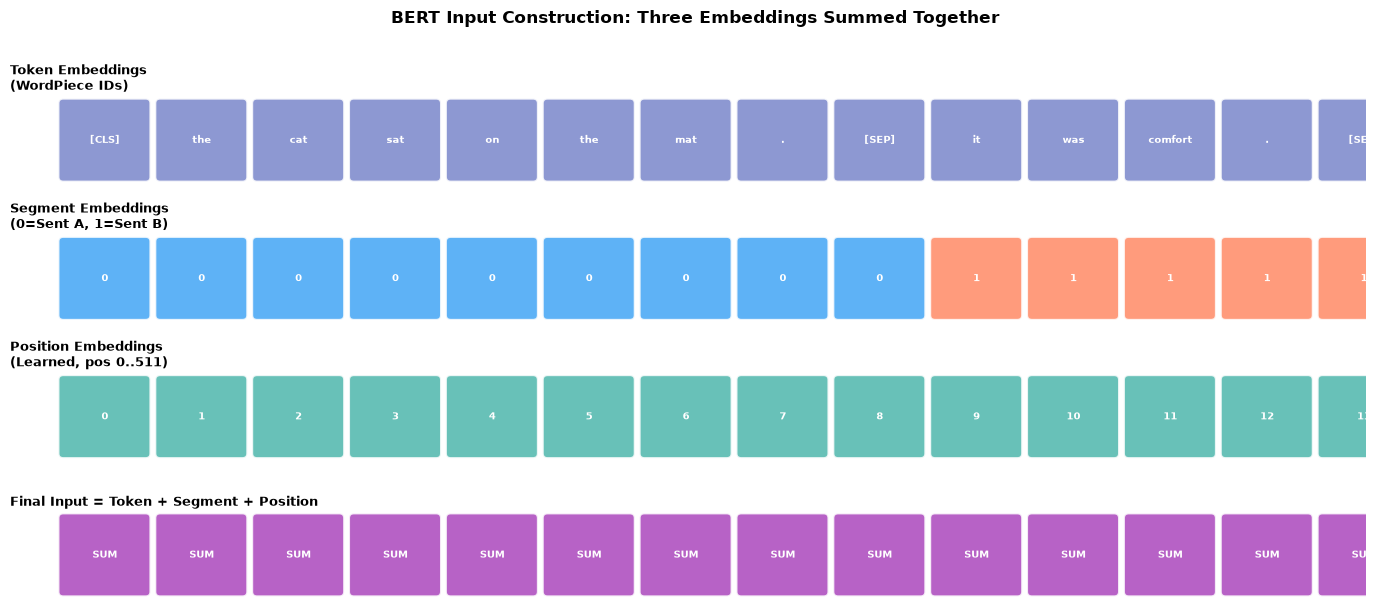

Total tokens: 14
[CLS] at position 0, [SEP] at positions []
Sentence A tokens: 9
Sentence B tokens: 5


In [1]:
# Visualize BERT's input embedding construction
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

sent_a = 'The cat sat on the mat.'
sent_b = 'It was comfortable.'
encoding = tokenizer(sent_a, sent_b, return_tensors='pt')
tokens   = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])
seg_ids  = encoding['token_type_ids'][0].tolist()
pos_ids  = list(range(len(tokens)))

n = len(tokens)
fig, axes = plt.subplots(4, 1, figsize=(14, 6))

row_configs = [
    (tokens,   ['#7986CB']*n,                           'Token Embeddings\n(WordPiece IDs)'),
    (seg_ids,  ['#42A5F5' if s==0 else '#FF8A65' for s in seg_ids], 'Segment Embeddings\n(0=Sent A, 1=Sent B)'),
    (pos_ids,  ['#4DB6AC']*n,                           'Position Embeddings\n(Learned, pos 0..511)'),
    (['SUM']*n, ['#AB47BC']*n,                          'Final Input = Token + Segment + Position'),
]

for ax, (vals, colors, title) in zip(axes, row_configs):
    ax.set_xlim(-0.5, n - 0.5)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(title, fontsize=9, fontweight='bold', loc='left', pad=2)
    for i, (tok, col) in enumerate(zip(tokens, colors)):
        rect = mpatches.FancyBboxPatch((i+0.05, 0.1), 0.85, 0.8,
                                        boxstyle='round,pad=0.05',
                                        facecolor=col, edgecolor='white', lw=1.5,
                                        alpha=0.85)
        ax.add_patch(rect)
        label = str(vals[i]) if len(str(vals[i])) < 8 else str(vals[i])[:7]
        ax.text(i+0.48, 0.5, label, ha='center', va='center',
                fontsize=7.5, fontweight='bold', color='white')

plt.suptitle("BERT Input Construction: Three Embeddings Summed Together",
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(r'outputs/p8_bert_input_construction.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Total tokens: {n}')
print(f'[CLS] at position 0, [SEP] at positions {[i for i,t in enumerate(tokens) if t=="[sep]"]}')
print(f'Sentence A tokens: {sum(1 for s in seg_ids if s==0)}')
print(f'Sentence B tokens: {sum(1 for s in seg_ids if s==1)}')

## 3. The `[CLS]` Token: BERT's Sentence-Level Antenna

BERT always prepends a special `[CLS]` (Classification) token at the very beginning of every input sequence. Why?

Because self-attention is bidirectional and global, every token's output representation is influenced by every other token. However, the model needs **one single vector that represents the entire input** for sentence-level tasks like classification.

The `[CLS]` token serves this role: since it has no inherent lexical meaning, it becomes a **free learnable slot** that the model uses to aggregate global sentence-level information through training. After passing through all 12 Transformer layers, the `[CLS]` output vector captures a holistic representation of the entire input.

> **Analogy**: Think of `[CLS]` as the chairperson in a meeting. Everyone in the room (all tokens) speaks, and the chairperson synthesizes the entire discussion into a final summary decision.

```
Input:  [CLS] The movie was fantastic [SEP]
Output: [h_CLS] [h_The] [h_movie] [h_was] [h_fantastic] [h_SEP]
                    ↑
               Only h_CLS is fed to the classification head
               It represents: "positive movie review"
```

---

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


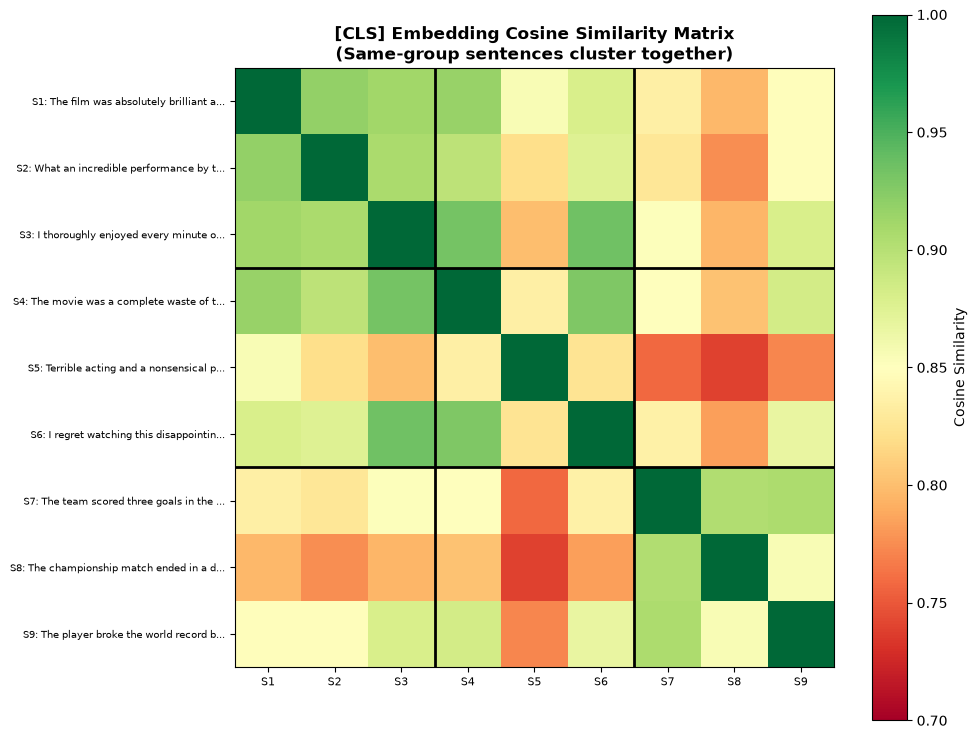

Observation: [CLS] embeddings within the same group (S1-S3, S4-S6, S7-S9) are
more similar to each other than to embeddings from different groups.
BERT learned domain separation purely from pre-training — no labels!


In [2]:
# Demonstrate how [CLS] aggregates sentence-level information
import torch
from transformers import BertTokenizer, BertModel
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')
model.eval()

def get_cls_embedding(text):
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=64)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[0, 0, :].numpy()  # [CLS] = position 0

# Sentences from different domains
sentences = {
    'Positive Sentiment': [
        'The film was absolutely brilliant and moving.',
        'What an incredible performance by the cast!',
        'I thoroughly enjoyed every minute of this masterpiece.',
    ],
    'Negative Sentiment': [
        'The movie was a complete waste of time.',
        'Terrible acting and a nonsensical plot.',
        'I regret watching this disappointing film.',
    ],
    'Sports News': [
        'The team scored three goals in the final quarter.',
        'The championship match ended in a dramatic penalty shootout.',
        'The player broke the world record by two seconds.',
    ],
}

all_sentences, all_labels, all_groups = [], [], []
colors = {'Positive Sentiment': '#4CAF50', 'Negative Sentiment': '#EF5350', 'Sports News': '#2196F3'}

for group, sents in sentences.items():
    for s in sents:
        all_sentences.append(s)
        all_labels.append(s[:35] + '...')
        all_groups.append(group)

embeddings = np.array([get_cls_embedding(s) for s in all_sentences])
sim_matrix = cosine_similarity(embeddings)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=0.7, vmax=1.0)
ax.set_xticks(range(len(all_labels)))
ax.set_yticks(range(len(all_labels)))
ax.set_xticklabels([f'S{i+1}' for i in range(len(all_labels))], fontsize=8)
ax.set_yticklabels([f'S{i+1}: {l}' for i,l in enumerate(all_labels)], fontsize=7)
ax.set_title('[CLS] Embedding Cosine Similarity Matrix\n(Same-group sentences cluster together)',
             fontsize=12, fontweight='bold')
# Add group divider lines
for boundary in [3, 6]:
    ax.axhline(boundary - 0.5, color='black', lw=2)
    ax.axvline(boundary - 0.5, color='black', lw=2)
plt.colorbar(im, ax=ax, label='Cosine Similarity')
plt.tight_layout()
plt.savefig(r'outputs/p8_cls_similarity_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: [CLS] embeddings within the same group (S1-S3, S4-S6, S7-S9) are')
print('more similar to each other than to embeddings from different groups.')
print('BERT learned domain separation purely from pre-training — no labels!')

## 4. What BERT's Attention Heads Learn

BERT-Base has 12 attention heads per layer × 12 layers = **144 attention heads** total. Research (Clark et al., 2019) probing these heads revealed that different heads specialize in specific linguistic patterns:

| Head Pattern | What It Captures | Example |
|---|---|---|
| **Syntactic dependency** | Subject-verb, modifier-noun relationships | "runs" attends strongly to "dog" |
| **Coreference** | Pronoun → antecedent resolution | "he" attends to "John" |
| **Next/previous token** | Local sequential relationships | Each token attends to neighbors |
| **[SEP] head** | Aggregation / sentence boundary | Many tokens attend to [SEP] |
| **[CLS] head** | Global sentence-level context | All tokens route through [CLS] |
| **Rare word focus** | Attends to infrequent, high-info tokens | Focus on nouns and verbs |

This specialization emerges **spontaneously** from pre-training — not from any explicit supervision.

---

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


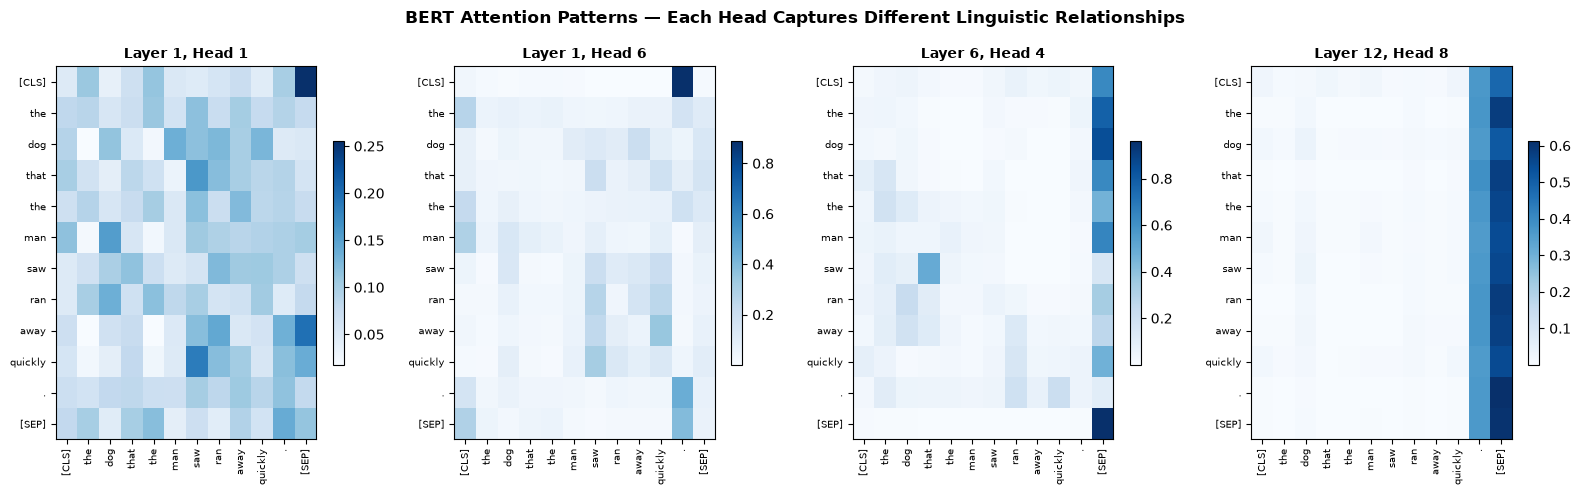

Each attention head learns to focus on different token relationships.
Some heads track local context; others track long-range dependencies.


In [3]:
# Extract and visualize BERT attention patterns
import torch
import matplotlib.pyplot as plt
import numpy as np
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)
model.eval()

sentence = 'The dog that the man saw ran away quickly.'
inputs = tokenizer(sentence, return_tensors='pt')
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

with torch.no_grad():
    outputs = model(**inputs)

# attentions shape: (num_layers, num_heads, seq_len, seq_len)
attentions = torch.stack(outputs.attentions)  # (12, 1, 12, seq_len, seq_len)
attentions = attentions.squeeze(1)             # (12, 12, seq_len, seq_len)

# Show 4 selected heads from different layers
selected = [(0, 0), (0, 5), (5, 3), (11, 7)]  # (layer, head) pairs
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, (layer, head) in zip(axes, selected):
    attn = attentions[layer, head].numpy()
    im = ax.imshow(attn, cmap='Blues', aspect='auto')
    ax.set_xticks(range(len(tokens)))
    ax.set_yticks(range(len(tokens)))
    ax.set_xticklabels(tokens, rotation=90, fontsize=7)
    ax.set_yticklabels(tokens, fontsize=7)
    ax.set_title(f'Layer {layer+1}, Head {head+1}', fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.6)

plt.suptitle("BERT Attention Patterns — Each Head Captures Different Linguistic Relationships",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(r'outputs/p8_bert_attention_heads.png', dpi=150, bbox_inches='tight')
plt.show()
print('Each attention head learns to focus on different token relationships.')
print('Some heads track local context; others track long-range dependencies.')

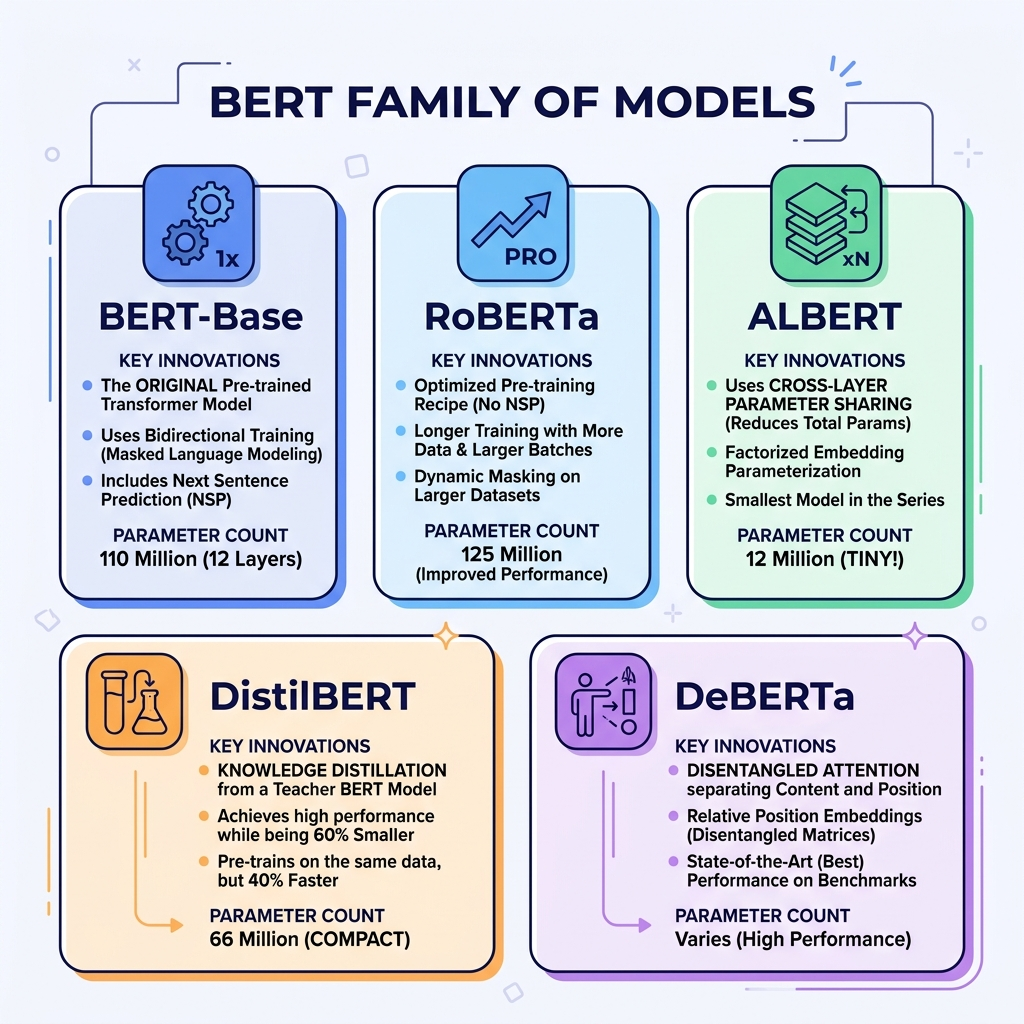

*Figure 3: The BERT Family — RoBERTa, ALBERT, DistilBERT, and DeBERTa each improve on the original in different ways*



## 5. The BERT Family: Key Improvements

### RoBERTa (Facebook, 2019)
RoBERTa found that the original BERT was **undertrained**. Changes:
- Trained 10× longer on 10× more data
- Removed NSP (found to hurt, not help)
- Used **dynamic masking** (different masks each epoch, not fixed)
- Larger mini-batches

Result: Significantly better performance with the same 12-layer architecture.

### ALBERT (Google, 2019)
Focused on **parameter efficiency** through two innovations:
- **Factorized Embedding Parametrization**: Separate the vocabulary embedding size from the hidden layer size. Use a small embedding (64-dim) projected to the hidden size.
- **Cross-Layer Parameter Sharing**: All 12 layers share the same weights. This dramatically reduces parameters (from 110M to 12M) at a modest performance cost.

### DistilBERT (Hugging Face, 2019)
Applied **knowledge distillation** — train a small 'student' model (6 layers) to mimic a large 'teacher' model (BERT-Base, 12 layers):
- 60% fewer parameters than BERT-Base
- 40% faster inference
- Retains 97% of BERT's language understanding

### DeBERTa (Microsoft, 2020)
Introduced **disentangled attention** — instead of representing each token with one vector that encodes both content and position, DeBERTa uses *two separate vectors* per token. This allows the attention to consider content-to-content, content-to-position, and position-to-content interactions independently, yielding state-of-the-art results.

---

## 6. Summary — Why BERT Was Revolutionary

| Achievement | Impact |
|---|---|
| SOTA on 11 NLP benchmarks simultaneously | Proved one architecture generalizes across tasks |
| Bidirectional context | Richer representations than any previous model |
| Pre-train once, fine-tune anywhere | Democratized NLP — small labs could fine-tune BERT |
| Open-sourced pre-trained weights | Entire community could build on top immediately |

### What's Next
Notebook 5 takes BERT from architecture to practice: we'll fine-tune it for sentiment classification and named entity recognition using the Hugging Face Trainer API.

---
*Phase 8, Notebook 4 of 10 — NLP From Scratch: Foundation to Advanced*